# needed libraries and functions

In [1]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [2]:
dataset = pd.read_csv('sentiment140.csv')
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   text               40000 non-null  object
 1   date               40000 non-null  object
 2   user               40000 non-null  object
 3   sentiment          40000 non-null  int64 
 4   query              40000 non-null  object
 5   __index_level_0__  40000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 1.8+ MB
None


In [3]:
texts = dataset['text']
print(texts.head())

0    Went to the park with my BFF. Wanted to get ab...
1    @zorocaster been a while since i had the chars...
2                            @stephjonesmusic YEs  lol
3    Hello everyone  Good Morning . . . . why is ma...
4    sooo, last night was fun. waking up for math w...
Name: text, dtype: object


In [4]:
text = " ".join(texts)

# remove stop words so important words appear in the visualization

In [5]:
# word counter
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to C:\Users\Ahmed
[nltk_data]     Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# word cloud visualization

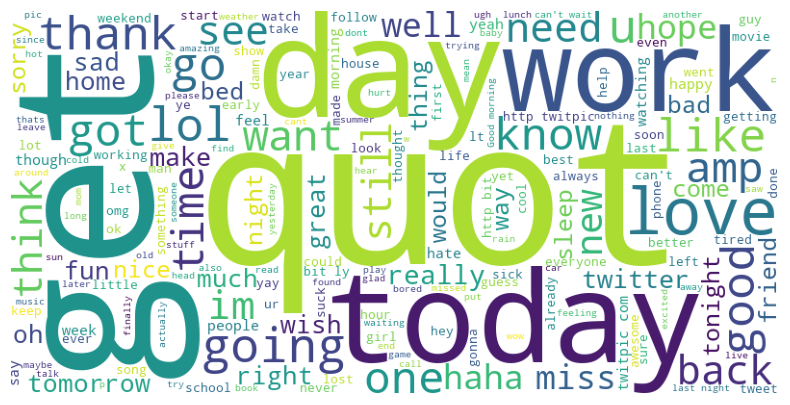

In [6]:
wc = WordCloud(width=800 , height=400 , background_color='white' , stopwords=stop_words).generate(text)
plt.figure(figsize=(10 , 5))
plt.imshow(wc)
plt.axis('off')
plt.show()

# frequancy visualization

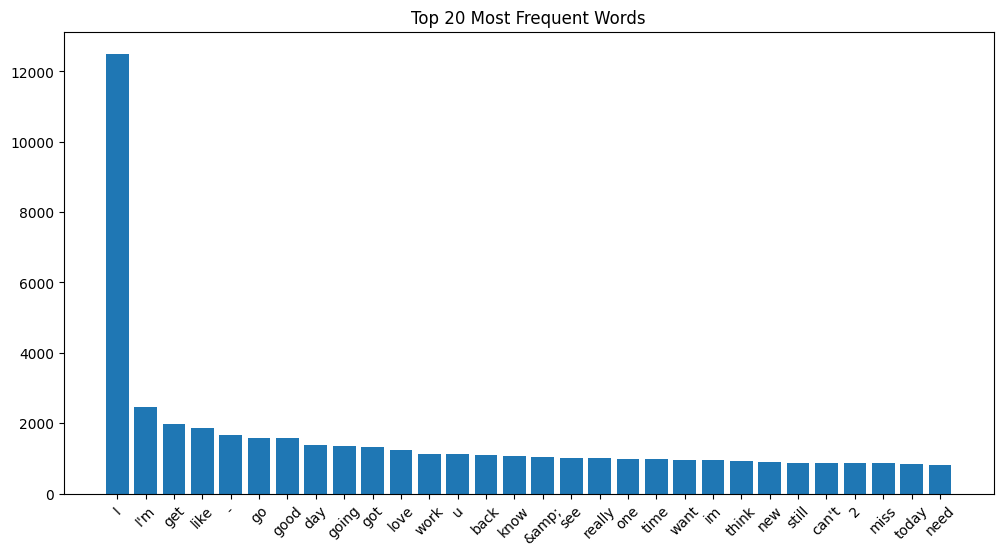

In [7]:
words = " ".join(texts).split()
filtered = [w for w in words if w not in stop_words]
word_freq = Counter(filtered)
common_words = word_freq.most_common(30)
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

In [8]:
X = dataset['text']
y = dataset['sentiment']
print(X , y)

0        Went to the park with my BFF. Wanted to get ab...
1        @zorocaster been a while since i had the chars...
2                                @stephjonesmusic YEs  lol
3        Hello everyone  Good Morning . . . . why is ma...
4        sooo, last night was fun. waking up for math w...
                               ...                        
39995    night was awesome (baby we can do it we can do...
39996    Just sat in english with a huge thing of tic t...
39997    @acheung219 i want some buffalo wings  i hear ...
39998                          @stephenfry  see you there 
39999           @jackscope hah, do it again please  miss u
Name: text, Length: 40000, dtype: object 0        0
1        0
2        1
3        1
4        0
        ..
39995    0
39996    1
39997    0
39998    1
39999    1
Name: sentiment, Length: 40000, dtype: int64


In [9]:
x_train , x_test , y_train , y_test = train_test_split(X , y , train_size=0.7 , random_state=42)
print(x_train)

38015    sleep? what's sleep again? I've seem to have f...
2281     Home frm wrk and in my pj's. Time to watch a m...
36629    @dwarfette http://twitpic.com/6p4y1 - You are ...
6087                                i'm compleately bored 
11792    @rockchick_30 Good morning Lisa! *HUG* I know ...
                               ...                        
6265     @Lore1 Good Morning Lore, was it you who just ...
11284    @mariagrineva one more proof of the small worl...
38158    @kassem_fci life is so boring. But i got a gre...
860           Lazy monday.. 7hours to go before knock off 
15795    Im tired and im waiting for mario strikers cha...
Name: text, Length: 28000, dtype: object


# tfidf vectorization on the train and test data

In [10]:
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)
print(x_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 330802 stored elements and shape (28000, 38472)>
  Coords	Values
  (0, 30934)	0.3675686731314914
  (0, 36850)	0.1529932059241091
  (0, 1846)	0.1792308028189624
  (0, 35973)	0.18215055964247484
  (0, 29851)	0.25656056837115765
  (0, 34363)	0.08052592113836682
  (0, 14951)	0.12302517113213299
  (0, 12904)	0.3777900516593579
  (0, 33634)	0.08305523803477023
  (0, 21753)	0.31360889708514483
  (0, 34529)	0.15163759647272013
  (0, 23207)	0.17105596642013485
  (0, 24874)	0.11864757134073006
  (0, 23386)	0.19588395279494952
  (0, 22322)	0.2394980015214521
  (0, 25011)	0.17853659147084947
  (0, 16916)	0.1011385419282542
  (0, 18244)	0.12777910882352947
  (0, 35819)	0.27847541238500434
  (0, 16629)	0.3777900516593579
  (1, 30934)	0.20006335866209368
  (1, 34363)	0.1753172935555079
  (1, 23386)	0.10661735988078981
  (1, 15558)	0.18114527569044633
  (1, 13176)	0.3484966270403187
  :	:
  (27997, 5706)	0.2386925681168159
  (27997, 33054)	

# applying KNN for sentiment predictions

In [11]:
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(x_train_tfidf , y_train)
predictions = knn.predict(x_test_tfidf)
print(predictions)

[1 1 0 ... 1 0 0]


# model accuracies

In [12]:
acc = accuracy_score(y_test , predictions)
con_mat = confusion_matrix(y_test , predictions)
class_report = classification_report(y_test , predictions)
print('accuracy: ,' , acc)
print('confusion matrix: \n', con_mat)
print('classification report \n: ', class_report)

accuracy: , 0.7084166666666667
confusion matrix: 
 [[4828 1256]
 [2243 3673]]
classification report 
:                precision    recall  f1-score   support

           0       0.68      0.79      0.73      6084
           1       0.75      0.62      0.68      5916

    accuracy                           0.71     12000
   macro avg       0.71      0.71      0.71     12000
weighted avg       0.71      0.71      0.71     12000



In [13]:
print(tfidf.get_feature_names_out())

['00' '000' '000th' ... 'ø¹' 'ø¹ø' 'ø¹ù']
